# LAB 4  
**Name:** Ashwin Rajan  
**Reg No:** 2448509

In [1]:
# If you're in a managed notebook (Colab/JupyterLab) you can run this directly.
# If everything is already installed, you can skip.
!pip install -q "qiskit>=1.2.4" "qiskit-aer>=0.15.1" matplotlib
!pip install pylatexenc


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 62.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 42.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 36.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 10.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=60712dfd2cf5000d61fa3ce4e3b1021b0980c3b78b02a528c94c27235495dcf6
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


## 2) Imports & Helpers

We import core Qiskit objects, visualization utilities, and define helper functions.

In [2]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, Operator
from qiskit_aer import Aer
from qiskit.visualization import plot_bloch_multivector, plot_histogram
import matplotlib.pyplot as plt

def simulate_sv_1q(circ: QuantumCircuit, basis_input: str = "0"):
    init = Statevector.from_label(basis_input)
    return init.evolve(circ)

def simulate_sv_2q(circ: QuantumCircuit, basis_input: str = "00"):
    init = Statevector.from_label(basis_input)
    return init.evolve(circ)

def measure_hist(circ: QuantumCircuit, shots: int = 4096):
    meas_circ = circ.copy()
    meas_circ.barrier()
    meas_circ.measure_all()
    backend = Aer.get_backend("aer_simulator")
    res = backend.run(meas_circ, shots=shots).result()
    return res.get_counts()

def show_bloch_1q(statevector: Statevector, title="Bloch Sphere"):
    fig = plot_bloch_multivector(statevector)
    plt.title(title)
    plt.show()

def pretty_sv(sv: Statevector, precision: int = 4):
    amps = np.array(sv.data)
    probs = np.abs(amps)**2
    basis_labels = [format(i, f'0{sv.num_qubits}b') for i in range(2**sv.num_qubits)]
    table = [(basis_labels[i], complex(round(amps[i].real, precision), round(amps[i].imag, precision)), round(probs[i], precision)) for i in range(len(amps))]
    return table


## 3) HSHT Circuit
We construct the HSHT operation on a single qubit.

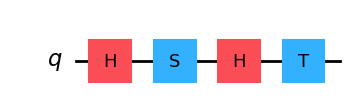

In [3]:
def hsht_circuit():
    qc = QuantumCircuit(1, name="HSHT")
    qc.h(0)
    qc.s(0)
    qc.h(0)
    qc.t(0)
    return qc

hsht = hsht_circuit()
display(hsht.draw("mpl"))


## 4) HSHT Outputs for Basis Inputs

HSHT |0> → statevector:
('0', (0.5+0.5j), np.float64(0.5))
('1', (0.7071+0j), np.float64(0.5))


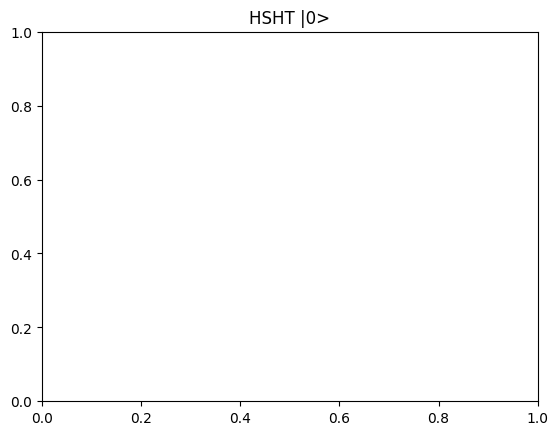

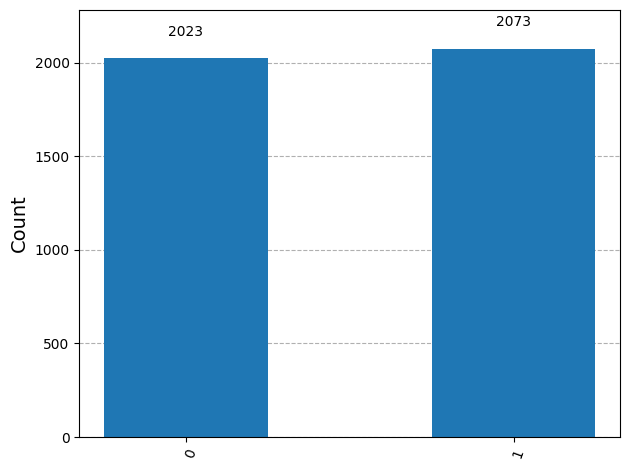


HSHT |1> → statevector:
('0', (0.5-0.5j), np.float64(0.5))
('1', 0.7071j, np.float64(0.5))


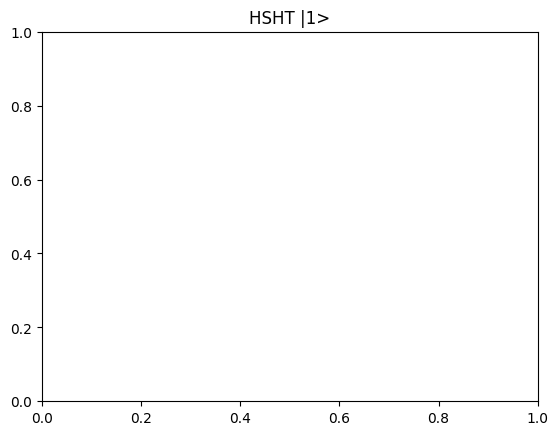

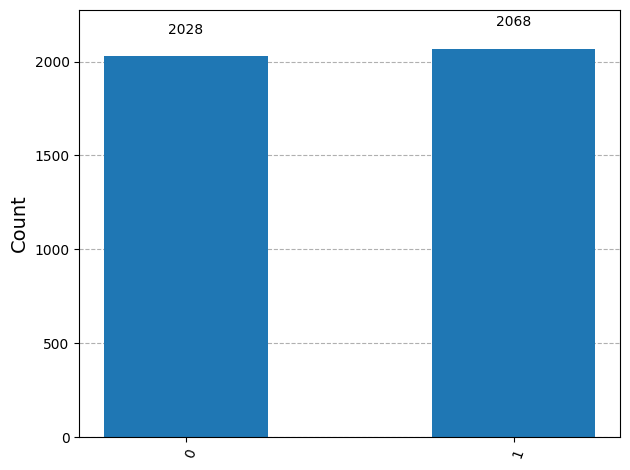

In [4]:
sv0 = simulate_sv_1q(hsht, "0")
print("HSHT |0> → statevector:")
for row in pretty_sv(sv0):
    print(row)
show_bloch_1q(sv0, title="HSHT |0>")

counts0 = measure_hist(hsht)
display(plot_histogram(counts0))

hsht_on_1 = QuantumCircuit(1)
hsht_on_1.x(0)
hsht_on_1.compose(hsht, inplace=True)

sv1 = simulate_sv_1q(hsht_on_1, "0")
print("\nHSHT |1> → statevector:")
for row in pretty_sv(sv1):
    print(row)
show_bloch_1q(sv1, title="HSHT |1>")
counts1 = measure_hist(hsht_on_1)
display(plot_histogram(counts1))


## 5) Reversibility of HSHT

‖U†U - I‖_F = 6.292624226552987e-16

After HSHT then HSHT† on |0> →
('0', (1+0j), np.float64(1.0))
('1', 0j, np.float64(0.0))

After HSHT then HSHT† on |1> →
('0', -0j, np.float64(0.0))
('1', (1+0j), np.float64(1.0))


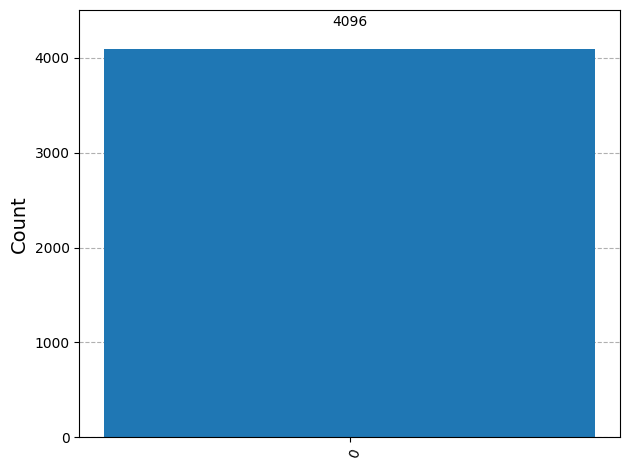

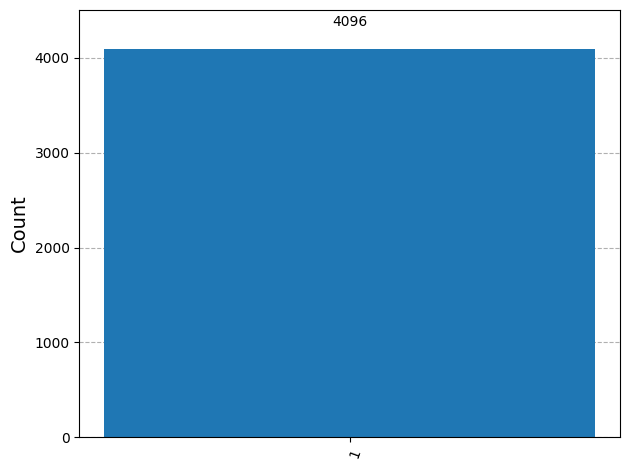

In [6]:
U = Operator(hsht)
UdagU = U.adjoint().data @ U.data
print("‖U†U - I‖_F =", np.linalg.norm(UdagU - np.eye(2)))

hsht_inv = hsht.inverse()
combo = QuantumCircuit(1)
combo.compose(hsht, inplace=True)
combo.compose(hsht_inv, inplace=True)

sv_id_0 = simulate_sv_1q(combo, "0")
sv_id_1 = simulate_sv_1q(combo, "1")
print("\nAfter HSHT then HSHT† on |0> →")
for row in pretty_sv(sv_id_0):
    print(row)
print("\nAfter HSHT then HSHT† on |1> →")
for row in pretty_sv(sv_id_1):
    print(row)
counts_back_0 = measure_hist(combo)
qc_for_counts_back_1 = QuantumCircuit(1)
qc_for_counts_back_1.x(0)
qc_for_counts_back_1.compose(combo, inplace=True)
counts_back_1 = measure_hist(qc_for_counts_back_1)
display(plot_histogram(counts_back_0))
display(plot_histogram(counts_back_1))

## 6) Entangling Circuit using H and CNOT

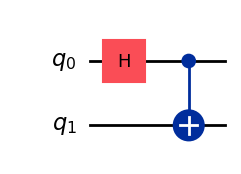

In [7]:
def bell_generator():
    qc = QuantumCircuit(2, name="H-CX")
    qc.h(0)
    qc.cx(0, 1)
    return qc

bell = bell_generator()
display(bell.draw("mpl"))


## 7) Outputs for Inputs |00>, |01>, |10>, |11>


=== Input |00⟩ → Expected Bell: Φ⁺  = (|00⟩ + |11⟩)/√2 ===
('00', (0.7071+0j), np.float64(0.5))
('01', 0j, np.float64(0.0))
('10', 0j, np.float64(0.0))
('11', (0.7071+0j), np.float64(0.5))


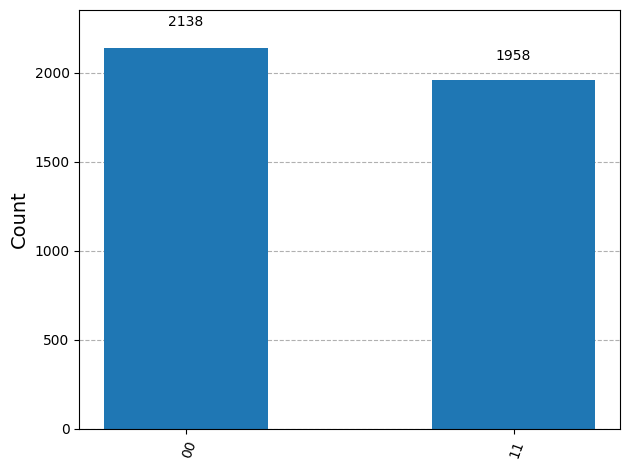


=== Input |01⟩ → Expected Bell: Ψ⁺  = (|01⟩ + |10⟩)/√2 ===
('00', 0j, np.float64(0.0))
('01', (0.7071+0j), np.float64(0.5))
('10', (0.7071+0j), np.float64(0.5))
('11', 0j, np.float64(0.0))


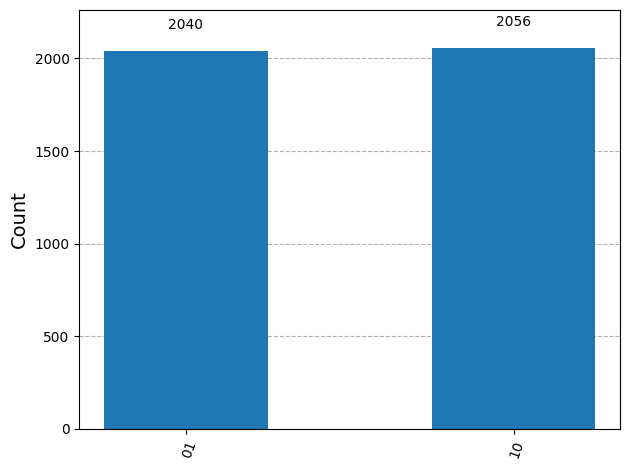


=== Input |10⟩ → Expected Bell: Φ⁻  = (|00⟩ − |11⟩)/√2 ===
('00', (0.7071+0j), np.float64(0.5))
('01', 0j, np.float64(0.0))
('10', 0j, np.float64(0.0))
('11', (-0.7071+0j), np.float64(0.5))


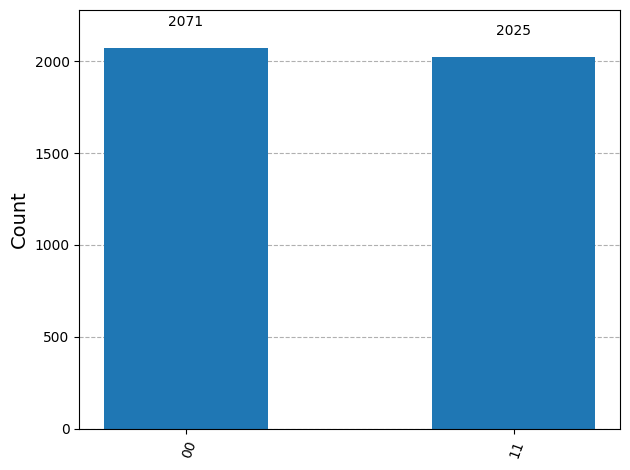


=== Input |11⟩ → Expected Bell: Ψ⁻  = (|01⟩ − |10⟩)/√2 ===
('00', 0j, np.float64(0.0))
('01', (-0.7071+0j), np.float64(0.5))
('10', (0.7071+0j), np.float64(0.5))
('11', 0j, np.float64(0.0))


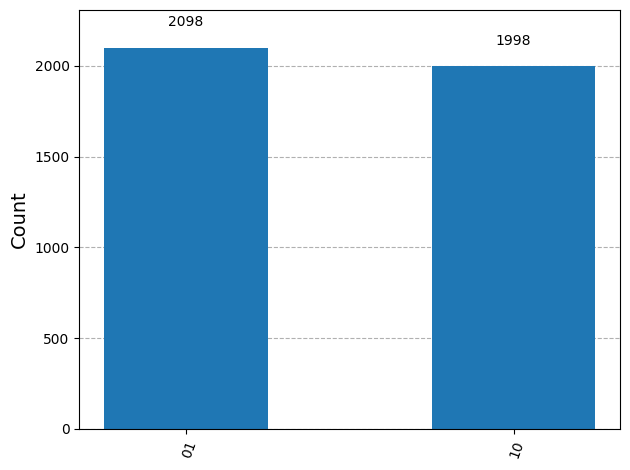

In [8]:
def prepare_input_2q(bits: str):
    qc = QuantumCircuit(2)
    if bits[0] == "1": qc.x(0)
    if bits[1] == "1": qc.x(1)
    return qc

def label_bell_from_input(bits: str) -> str:
    return {
        "00": "Φ⁺  = (|00⟩ + |11⟩)/√2",
        "01": "Ψ⁺  = (|01⟩ + |10⟩)/√2",
        "10": "Φ⁻  = (|00⟩ − |11⟩)/√2",
        "11": "Ψ⁻  = (|01⟩ − |10⟩)/√2",
    }[bits]

for bits in ("00", "01", "10", "11"):
    print(f"\n=== Input |{bits}⟩ → Expected Bell: {label_bell_from_input(bits)} ===")
    prep = prepare_input_2q(bits)
    full = prep.compose(bell, inplace=False)
    sv = simulate_sv_2q(full, "00")
    for row in pretty_sv(sv):
        print(row)
    counts = measure_hist(full)
    display(plot_histogram(counts))


## 8) Comments & Bell-State Relation

HSHT is unitary and reversible. H–CNOT circuit generates Bell states (Φ⁺, Ψ⁺, Φ⁻, Ψ⁻).